# Backtester básico

El objetivo de este notebook es empezar a construir una estructura reutilizable para evaluar estrategias.

Durante el Sprint 1 calculé una estrategia buy and hold directamente.

En este Sprint 2 quiero separar mejor los elementos:

- precio;
- rendimientos;
- posición;
- rendimientos de estrategia;
- curva de capital;
- métricas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [2]:
cwd = Path.cwd()

if (cwd / "requirements.txt").exists():
    project_root = cwd
else:
    project_root = cwd.parent

processed_file = project_root / "data" / "processed" / "SPY_daily.csv"
raw_file = project_root / "data" / "raw" / "SPY_daily.csv"
raw_file_alt = project_root / "data" / "raw" / "SPY_daily_raw.csv"

if processed_file.exists():
    data_file = processed_file
elif raw_file.exists():
    data_file = raw_file
elif raw_file_alt.exists():
    data_file = raw_file_alt
else:
    raise FileNotFoundError("No encuentro el CSV de SPY.")

print("Raíz del proyecto:", project_root)
print("Archivo usado:", data_file)

Raíz del proyecto: c:\Users\usuario\Documents\GitHub\QuantLab
Archivo usado: c:\Users\usuario\Documents\GitHub\QuantLab\data\processed\SPY_daily.csv


In [3]:
spy = pd.read_csv(data_file, index_col=0, parse_dates=True)

spy.head()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
1993-01-29,24.113268,43.93750,43.96875,43.75000,43.96875,1003200
1993-02-01,24.284761,44.25000,44.25000,43.96875,43.96875,480500
1993-02-02,24.336224,44.34375,44.37500,44.12500,44.21875,201300
1993-02-03,24.593477,44.81250,44.84375,44.37500,44.40625,529400
1993-02-04,24.696363,45.00000,45.09375,44.46875,44.96875,531500


In [4]:
price = spy["Adj Close"].copy()

price.head()

Date
1993-01-29    24.113268
1993-02-01    24.284761
1993-02-02    24.336224
1993-02-03    24.593477
1993-02-04    24.696363
Name: Adj Close, dtype: float64

In [5]:
returns = price.pct_change().dropna()

returns.head()

Date
1993-02-01    0.007112
1993-02-02    0.002119
1993-02-03    0.010571
1993-02-04    0.004183
1993-02-05   -0.000694
Name: Adj Close, dtype: float64

## Rendimientos diarios

Los rendimientos diarios miden el cambio porcentual del precio ajustado entre dos sesiones consecutivas.

La fórmula es:

R_t = P_t / P_{t-1} - 1

En este notebook, `returns` representa los rendimientos diarios de SPY.

In [6]:
buy_and_hold_equity = (1 + returns).cumprod()

buy_and_hold_equity.head()

Date
1993-02-01    1.007112
1993-02-02    1.009246
1993-02-03    1.019915
1993-02-04    1.024182
1993-02-05    1.023471
Name: Adj Close, dtype: float64

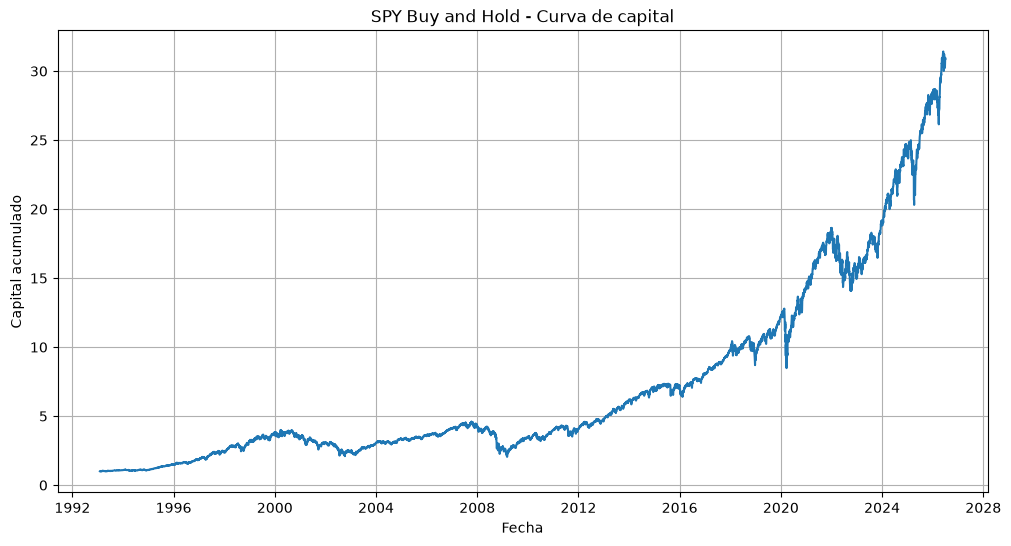

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(buy_and_hold_equity.index, buy_and_hold_equity)
plt.title("SPY Buy and Hold - Curva de capital")
plt.xlabel("Fecha")
plt.ylabel("Capital acumulado")
plt.grid(True)
plt.show()

In [8]:
total_return = buy_and_hold_equity.iloc[-1] - 1

start_date = buy_and_hold_equity.index[0]
end_date = buy_and_hold_equity.index[-1]
years = (end_date - start_date).days / 365.25

annualized_return = buy_and_hold_equity.iloc[-1] ** (1 / years) - 1
annualized_volatility = returns.std() * np.sqrt(252)

running_max = buy_and_hold_equity.cummax()
drawdown = buy_and_hold_equity / running_max - 1
max_drawdown = drawdown.min()

summary = pd.Series({
    "Rentabilidad total": total_return,
    "Rentabilidad anualizada": annualized_return,
    "Volatilidad anualizada": annualized_volatility,
    "Máximo drawdown": max_drawdown
})

summary_percent = summary * 100

summary_percent

Rentabilidad total         2988.673142
Rentabilidad anualizada      10.812041
Volatilidad anualizada       18.573180
Máximo drawdown             -55.189449
dtype: float64

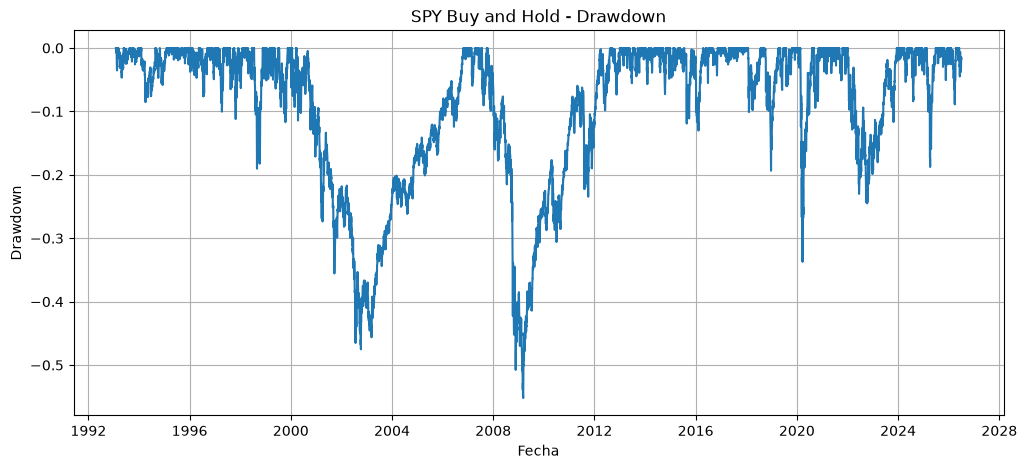

In [9]:
plt.figure(figsize=(12, 5))
plt.plot(drawdown.index, drawdown)
plt.title("SPY Buy and Hold - Drawdown")
plt.xlabel("Fecha")
plt.ylabel("Drawdown")
plt.grid(True)
plt.show()

## Conclusiones del día

En este notebook he reproducido la estrategia buy and hold de SPY.

El flujo básico ha sido:

precio ajustado → rendimientos diarios → curva de capital → métricas

Este notebook todavía no es un backtester completo, pero prepara la estructura que se convertirá en uno.

La siguiente mejora será separar explícitamente la posición de la estrategia. En buy and hold, la posición será simplemente estar invertido todo el tiempo.

## Precio, rendimiento y curva de capital

El precio (`price`) representa el valor de SPY en cada fecha.

El rendimiento diario (`returns`) mide el cambio porcentual entre el precio de un día y el precio del día anterior:

R_t = P_t / P_{t-1} - 1

La curva de capital (`buy_and_hold_equity`) representa cómo habría evolucionado una unidad monetaria invertida al inicio.

La diferencia es importante:

- el precio está en dólares;
- el rendimiento está en porcentaje o tanto por uno;
- la curva de capital está normalizada, empezando en 1.

Por ejemplo, si la curva de capital vale 3, significa que una inversión inicial de 1 se habría convertido en 3.

In [10]:
check = pd.DataFrame({
    "price": price,
    "return": returns,
    "equity_curve": buy_and_hold_equity
})

check.head(10)

,price,return,equity_curve
Date,,,
1993-01-29,24.113268,NaN,NaN
1993-02-01,24.284761,0.007112,1.007112
1993-02-02,24.336224,0.002119,1.009246
1993-02-03,24.593477,0.010571,1.019915
1993-02-04,24.696363,0.004183,1.024182
1993-02-05,24.679234,-0.000694,1.023471
1993-02-08,24.679234,0.000000,1.023471
1993-02-09,24.507721,-0.006950,1.016358
1993-02-10,24.542025,0.001400,1.017781


# Señales y posiciones

En un backtest conviene separar la rentabilidad del activo de la posición de la estrategia.

El activo tiene unos rendimientos diarios, representados por `returns`.

La estrategia decide qué exposición quiere tener mediante una posición:

- posición = 1 significa estar invertido;
- posición = 0 significa estar fuera del mercado;
- posición = -1 significaría estar corto, aunque todavía no usaremos posiciones cortas.

Para evitar usar información futura, la posición calculada hoy debe aplicarse al rendimiento del día siguiente.

In [11]:
position = pd.Series(1, index=returns.index)

position.head()

Date
1993-02-01    1
1993-02-02    1
1993-02-03    1
1993-02-04    1
1993-02-05    1
dtype: int64

In [12]:
strategy_returns = position.shift(1) * returns
strategy_returns = strategy_returns.dropna()

strategy_returns.head()

Date
1993-02-02    0.002119
1993-02-03    0.010571
1993-02-04    0.004183
1993-02-05   -0.000694
1993-02-08    0.000000
dtype: float64

In [13]:
strategy_equity = (1 + strategy_returns).cumprod()

strategy_equity.head()

Date
1993-02-02    1.002119
1993-02-03    1.012712
1993-02-04    1.016949
1993-02-05    1.016244
1993-02-08    1.016244
dtype: float64

In [14]:
comparison = pd.DataFrame({
    "buy_and_hold_direct": buy_and_hold_equity,
    "strategy_with_position": strategy_equity
})

comparison.head(10)

,buy_and_hold_direct,strategy_with_position
Date,,
1993-02-01,1.007112,NaN
1993-02-02,1.009246,1.002119
1993-02-03,1.019915,1.012712
1993-02-04,1.024182,1.016949
1993-02-05,1.023471,1.016244
1993-02-08,1.023471,1.016244
1993-02-09,1.016358,1.009181
1993-02-10,1.017781,1.010594
1993-02-11,1.022759,1.015537


In [15]:
comparison.tail()

,buy_and_hold_direct,strategy_with_position
Date,,
2026-06-26,30.231904,30.018413
2026-06-29,30.729970,30.512962
2026-06-30,30.969258,30.750560
2026-07-01,30.927372,30.708970
2026-07-02,30.886731,30.668616


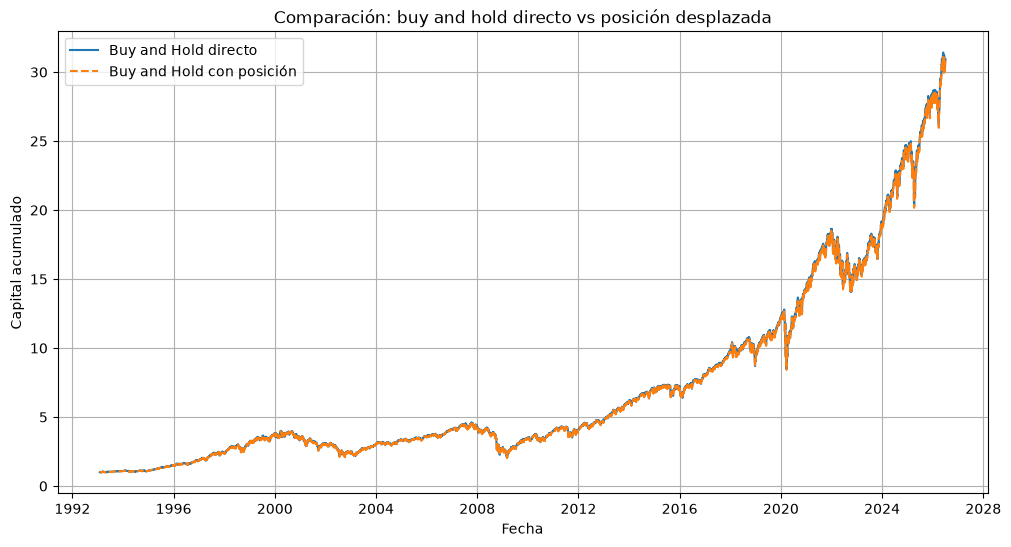

In [16]:
plt.figure(figsize=(12, 6))
plt.plot(comparison.index, comparison["buy_and_hold_direct"], label="Buy and Hold directo")
plt.plot(comparison.index, comparison["strategy_with_position"], label="Buy and Hold con posición", linestyle="--")
plt.title("Comparación: buy and hold directo vs posición desplazada")
plt.xlabel("Fecha")
plt.ylabel("Capital acumulado")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
total_return_position = strategy_equity.iloc[-1] - 1

start_date = strategy_equity.index[0]
end_date = strategy_equity.index[-1]
years = (end_date - start_date).days / 365.25

annualized_return_position = strategy_equity.iloc[-1] ** (1 / years) - 1
annualized_volatility_position = strategy_returns.std() * np.sqrt(252)

running_max_position = strategy_equity.cummax()
drawdown_position = strategy_equity / running_max_position - 1
max_drawdown_position = drawdown_position.min()

summary_position = pd.Series({
    "Rentabilidad total": total_return_position,
    "Rentabilidad anualizada": annualized_return_position,
    "Volatilidad anualizada": annualized_volatility_position,
    "Máximo drawdown": max_drawdown_position
})

summary_position * 100

Rentabilidad total         2966.861626
Rentabilidad anualizada      10.789471
Volatilidad anualizada       18.573929
Máximo drawdown             -55.189449
dtype: float64

## Conclusiones sobre posiciones

He separado explícitamente los rendimientos del activo y la posición de la estrategia.

En el caso de buy and hold, la posición es igual a 1 todos los días.

El rendimiento de la estrategia se calcula como:

strategy_returns = position.shift(1) * returns

El desplazamiento con `shift(1)` es importante porque evita usar información futura. La posición que se decide con información disponible hasta el día anterior se aplica al rendimiento del día actual.

La curva obtenida con posiciones debería ser casi idéntica a la curva buy and hold directa, salvo pequeñas diferencias por el primer día perdido.

returns mide el rendimiento diario de SPY.

position mide si la estrategia está invertida o no.

strategy_returns mide lo que realmente gana la estrategia después de aplicar la posición.

Uso position.shift(1) para no aplicar una decisión tomada hoy al rendimiento de hoy.

In [18]:
returns = price.pct_change().dropna()

position1 = pd.Series(0, index=returns.index)
position2 = np.sign(returns)

position = np.maximum(position1, position2)

#position = (returns > 0).astype(int)

In [19]:
strategy_returns = position.shift(1) * returns
strategy_returns = strategy_returns.dropna()

strategy_returns.head()

Date
1993-02-02    0.002119
1993-02-03    0.010571
1993-02-04    0.004183
1993-02-05   -0.000694
1993-02-08    0.000000
dtype: float64

In [20]:
previous_day_position = (returns > 0).astype(int)

previous_day_strategy_returns = previous_day_position.shift(1) * returns
previous_day_strategy_returns = previous_day_strategy_returns.dropna()

previous_day_equity = (1 + previous_day_strategy_returns).cumprod()

previous_day_equity.head()

Date
1993-02-02    1.002119
1993-02-03    1.012712
1993-02-04    1.016949
1993-02-05    1.016244
1993-02-08    1.016244
Name: Adj Close, dtype: float64

In [21]:
previous_day_position.value_counts(normalize=True)

Adj Close
1    0.540894
0    0.459106
Name: proportion, dtype: float64

In [22]:
comparison_prevDay = pd.DataFrame({
    "buy_and_hold_direct": buy_and_hold_equity,
    "strategy_with_position": previous_day_equity
})

comparison_prevDay.head(10)

,buy_and_hold_direct,strategy_with_position
Date,,
1993-02-01,1.007112,NaN
1993-02-02,1.009246,1.002119
1993-02-03,1.019915,1.012712
1993-02-04,1.024182,1.016949
1993-02-05,1.023471,1.016244
1993-02-08,1.023471,1.016244
1993-02-09,1.016358,1.016244
1993-02-10,1.017781,1.016244
1993-02-11,1.022759,1.021214


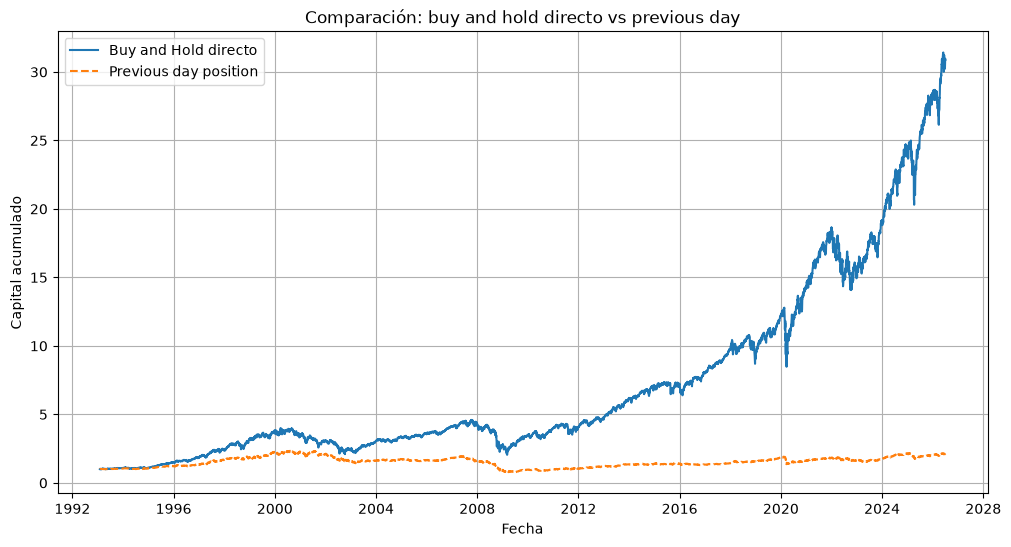

In [23]:
plt.figure(figsize=(12, 6))
plt.plot(comparison_prevDay.index, comparison_prevDay["buy_and_hold_direct"], label="Buy and Hold directo")
plt.plot(comparison_prevDay.index, comparison_prevDay["strategy_with_position"], label="Previous day position", linestyle="--")
plt.title("Comparación: buy and hold directo vs previous day")
plt.xlabel("Fecha")
plt.ylabel("Capital acumulado")
plt.legend()
plt.grid(True)
plt.show()

In [24]:
diagnostic = pd.DataFrame({
    "return_today": returns,
    "return_yesterday": returns.shift(1),
    "position": position.shift(1)
}).dropna()

diagnostic.groupby("position")["return_today"].mean()

position
0.0    0.000778
1.0    0.000219
Name: return_today, dtype: float64

In [25]:
previous_day_strategy_equity = (1 + previous_day_strategy_returns).cumprod()

total_return_position = previous_day_strategy_equity.iloc[-1] - 1

start_date = previous_day_strategy_equity.index[0]
end_date = previous_day_strategy_equity.index[-1]
years = (end_date - start_date).days / 365.25

annualized_return_position = previous_day_strategy_equity.iloc[-1] ** (1 / years) - 1
annualized_volatility_position = previous_day_strategy_returns.std() * np.sqrt(252)

running_max_position = previous_day_strategy_equity.cummax()
drawdown_position = previous_day_strategy_equity / running_max_position - 1
max_drawdown_position = drawdown_position.min()

summary_position = pd.Series({
    "Rentabilidad total": total_return_position,
    "Rentabilidad anualizada": annualized_return_position,
    "Volatilidad anualizada": annualized_volatility_position,
    "Máximo drawdown": max_drawdown_position
})

summary_position * 100

Rentabilidad total         111.125699
Rentabilidad anualizada      2.261908
Volatilidad anualizada      12.173633
Máximo drawdown            -67.739583
dtype: float64

In [26]:
import sys
sys.path.append("../")

from src.metrics import (
    total_return,
    annualized_return,
    annualized_volatility,
    drawdown,
    max_drawdown,
    performance_summary,
)

In [27]:
import sys
sys.path.append("../")

import src.metrics as metrics

print(metrics.__file__)
print(dir(metrics))

c:\Users\usuario\Documents\GitHub\QuantLab\notebooks\..\src\metrics.py
['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'annualized_return', 'annualized_volatility', 'drawdown', 'max_drawdown', 'np', 'pd', 'performance_summary', 'total_return']


In [28]:
from pathlib import Path

path = Path("../src/metrics.py")
print(path.resolve())
print(path.read_text(encoding="utf-8"))

C:\Users\usuario\Documents\GitHub\QuantLab\src\metrics.py
import pandas as pd
import numpy as np


def total_return(equity_curve):
    """
    Calcula la rentabilidad total de una curva de capital.
    """
    return equity_curve.iloc[-1] / equity_curve.iloc[0] - 1


def annualized_return(equity_curve, periods_per_year=252):
    """
    Calcula la rentabilidad anualizada de una curva de capital.
    """
    total_ret = total_return(equity_curve)
    num_periods = len(equity_curve)
    num_years = num_periods / periods_per_year

    return (1 + total_ret) ** (1 / num_years) - 1


def annualized_volatility(returns, periods_per_year=252):
    """
    Calcula la volatilidad anualizada a partir de retornos periódicos.
    """
    return returns.std() * np.sqrt(periods_per_year)


def drawdown(equity_curve):
    """
    Calcula la serie de drawdowns de una curva de capital.
    """
    running_max = equity_curve.cummax()
    return equity_curve / running_max - 1


def max_drawdown(equity_cur

In [29]:
import sys
import importlib

sys.path.append("../")

import src.metrics as metrics

importlib.reload(metrics)

print(metrics.__file__)
print([name for name in dir(metrics) if not name.startswith("_")])

c:\Users\usuario\Documents\GitHub\QuantLab\notebooks\..\src\metrics.py
['annualized_return', 'annualized_volatility', 'drawdown', 'max_drawdown', 'np', 'pd', 'performance_summary', 'total_return']


In [33]:
buy_and_hold_summary=performance_summary(buy_and_hold_equity,returns)


In [32]:
previous_day_summary=performance_summary(previous_day_equity,returns)

In [34]:
summary = pd.DataFrame({
    "Buy and Hold": buy_and_hold_summary,
    "Previous Day": previous_day_summary,
})

summary

,Buy and Hold,Previous Day
Total Return,29.668616,1.106792
Annualized Return,0.107993,0.022577
Annualized Volatility,0.185732,0.185732
Max Drawdown,-0.551894,-0.677396


In [36]:
summary_pct = summary.map(lambda x: f"{x:.2%}")
summary_pct

,Buy and Hold,Previous Day
Total Return,2966.86%,110.68%
Annualized Return,10.80%,2.26%
Annualized Volatility,18.57%,18.57%
Max Drawdown,-55.19%,-67.74%
